# Влияние нефтяного рынка на курс рубля

Авторы: Мережкин Олег, Мамедов Сабухи, Заренков Пётр

## 1. Введение

В проекте сравниваем Brent, WTI и отдельный месячный блок Dubai. Цель — понять, какие нефтяные признаки лучше объясняют USD/RUB.

In [1]:
from pathlib import Path
import os
import sys

# Ноутбук лежит в presentations/ — рабочая папка должна быть корень проекта
ROOT = Path.cwd()
if not (ROOT / "src.py").exists() and (ROOT.parent / "src.py").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display
import src

if not Path("data/model_results.csv").exists():
    src.main()

## 2. Данные

Основная дневная выборка хранится в `data/daily_features.csv`. Месячные бенчмарки с Dubai — в `data/monthly_benchmarks.csv`.

In [2]:
daily = pd.read_csv('data/daily_features.csv', parse_dates=['date'])
monthly = pd.read_csv('data/monthly_benchmarks.csv', parse_dates=['date'])
results = pd.read_csv('data/model_results.csv')
importance = pd.read_csv('data/feature_importance.csv')

display(daily.head())
print(daily.shape)
display(monthly.head())

,date,usdrub,brent,wti,usdrub_return,brent_return,wti_return,brent_ma7,brent_vol7,brent_ma30,...,brent_lag30,wti_ma7,wti_vol7,wti_ma30,wti_vol30,wti_lag1,wti_lag3,wti_lag7,wti_lag14,wti_lag30
0,2014-02-13,34.797199,108.730003,100.349998,0.002082,-0.000551,-0.000199,108.262858,0.009622,107.333000,...,107.779999,99.402856,0.007480,96.012000,0.009716,100.370003,100.059998,97.190002,96.639999,95.440002
1,2014-02-14,35.079399,108.730003,100.300003,0.008110,0.000000,-0.000498,108.617144,0.009732,107.394333,...,106.889999,99.820000,0.007679,96.223334,0.009169,100.349998,99.940002,97.379997,95.720001,93.959999
2,2014-02-17,35.082500,108.730003,100.300003,0.000088,0.000000,0.000000,108.837144,0.009468,107.461000,...,106.730003,100.171429,0.007837,96.452334,0.009059,100.300003,100.370003,97.839996,97.410004,93.430000
3,2014-02-18,35.194801,108.730003,102.430000,0.003201,0.000000,0.021236,108.717145,0.003336,107.507000,...,107.349998,100.535715,0.007979,96.744334,0.009690,100.300003,100.349998,99.879997,97.360001,93.669998
4,2014-02-19,35.418499,110.470001,103.309998,0.006356,0.016003,0.008591,108.980002,0.006010,107.617667,...,107.150002,101.000001,0.008130,97.110334,0.009165,102.430000,100.300003,100.059998,98.230003,92.330002


(2839, 25)


,date,usdrub,brent,wti,dubai,urals
0,2014-01-31,34.903301,106.400002,97.489998,103.767826,104.3868
1,2014-02-28,35.990898,109.070000,102.589996,105.258500,105.9085
2,2014-03-31,35.551498,107.760002,101.580002,104.344286,105.0576
3,2014-04-30,35.620399,108.070000,99.739998,104.820909,105.3191
4,2014-05-31,34.617699,109.410004,102.709999,105.534091,106.4795


## 3. EDA

Сначала смотрим динамику нефти и USD/RUB. На графиках должны быть заметны кризисные периоды и резкие движения курса.

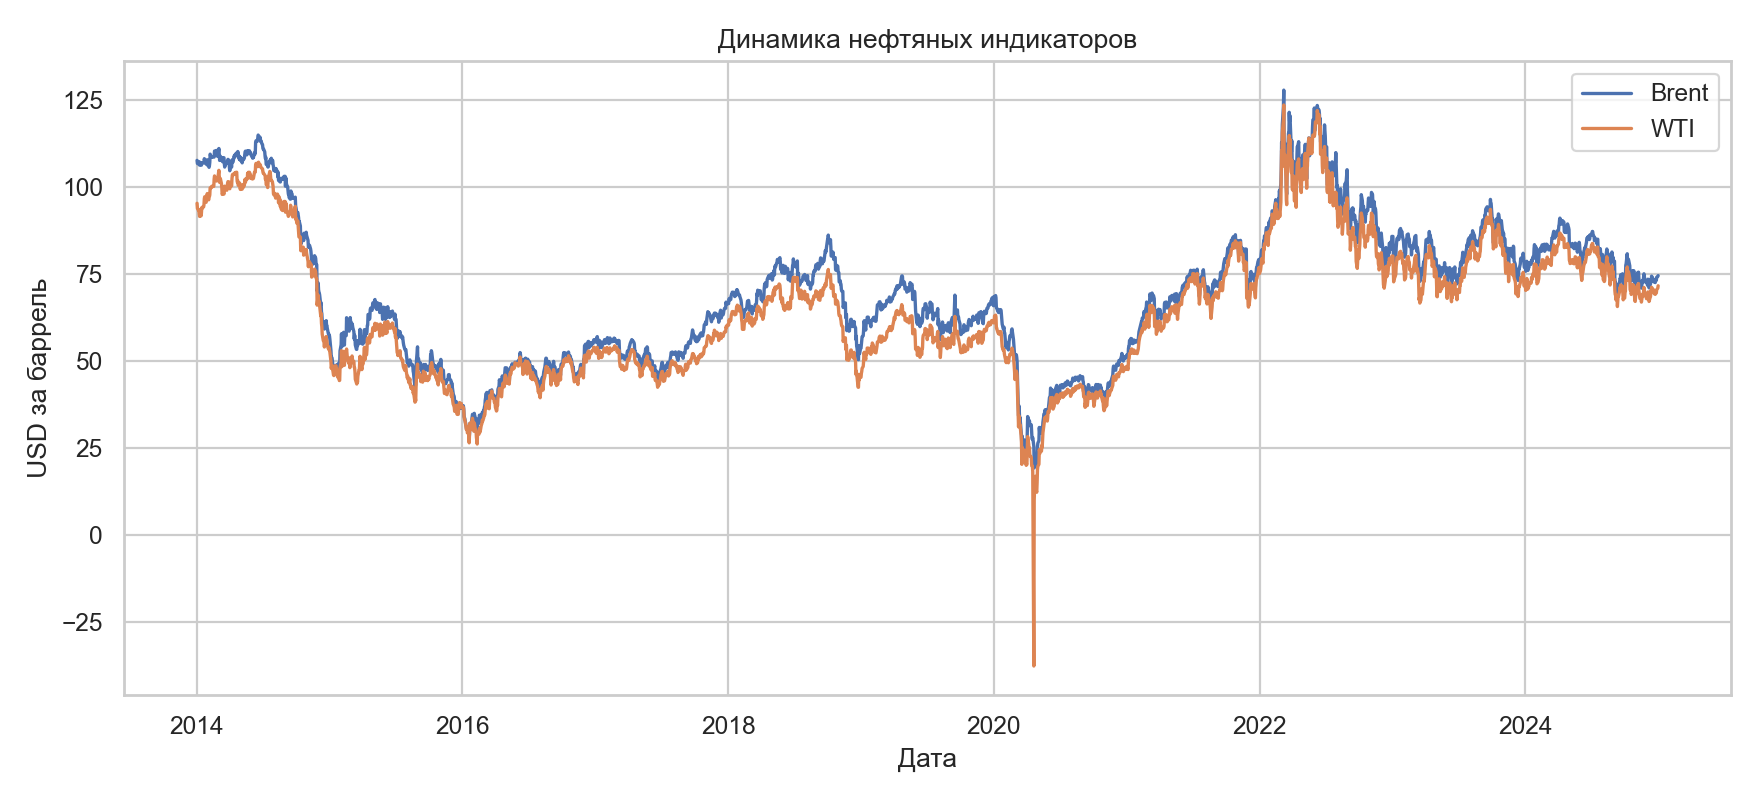

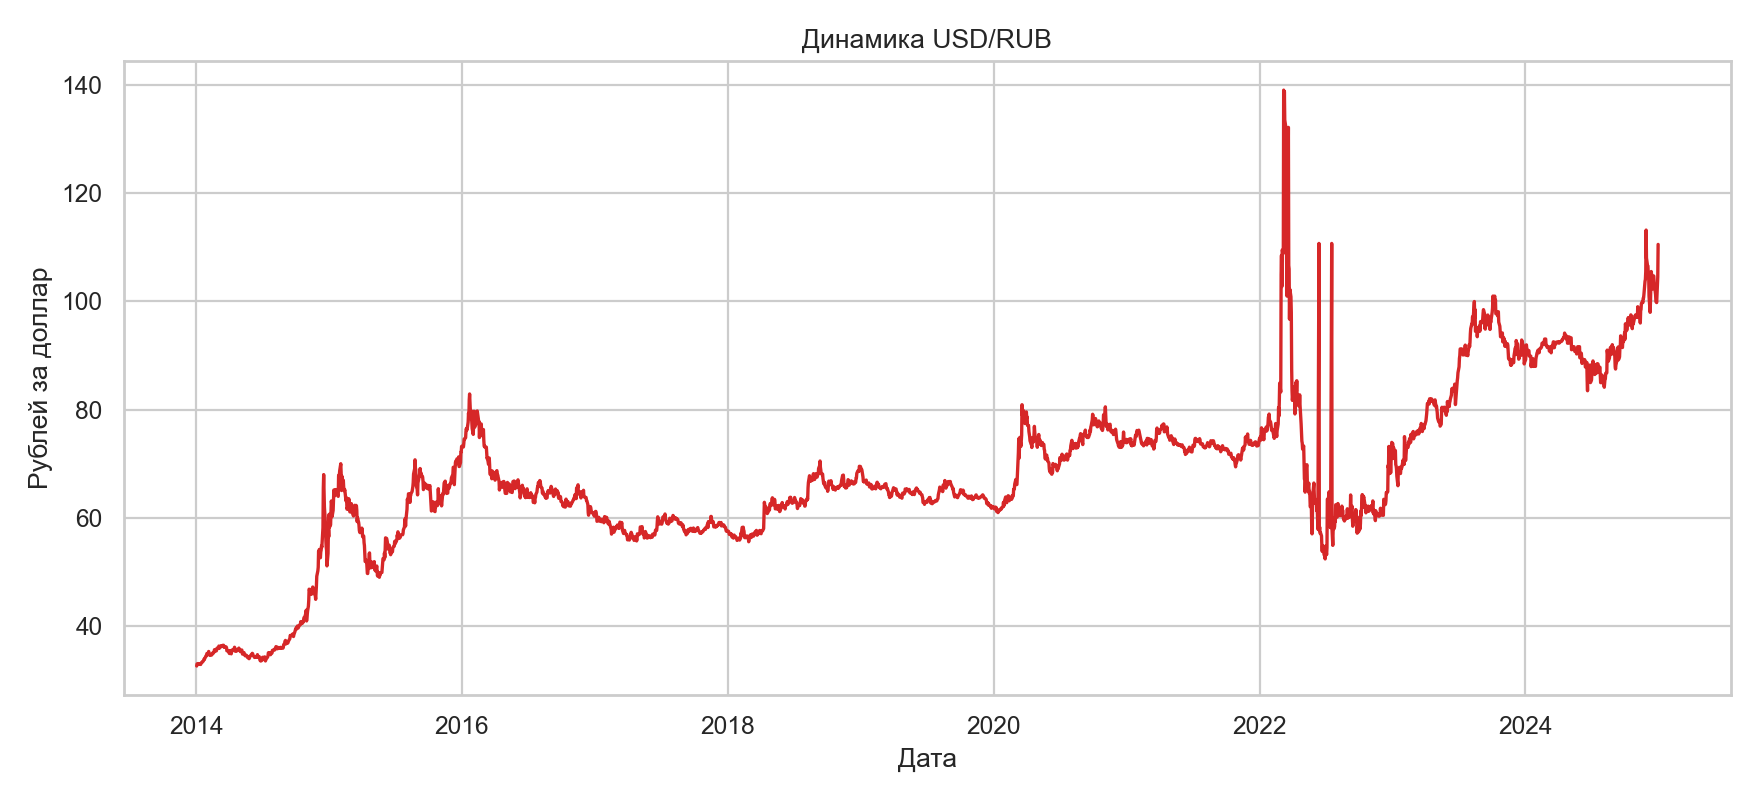

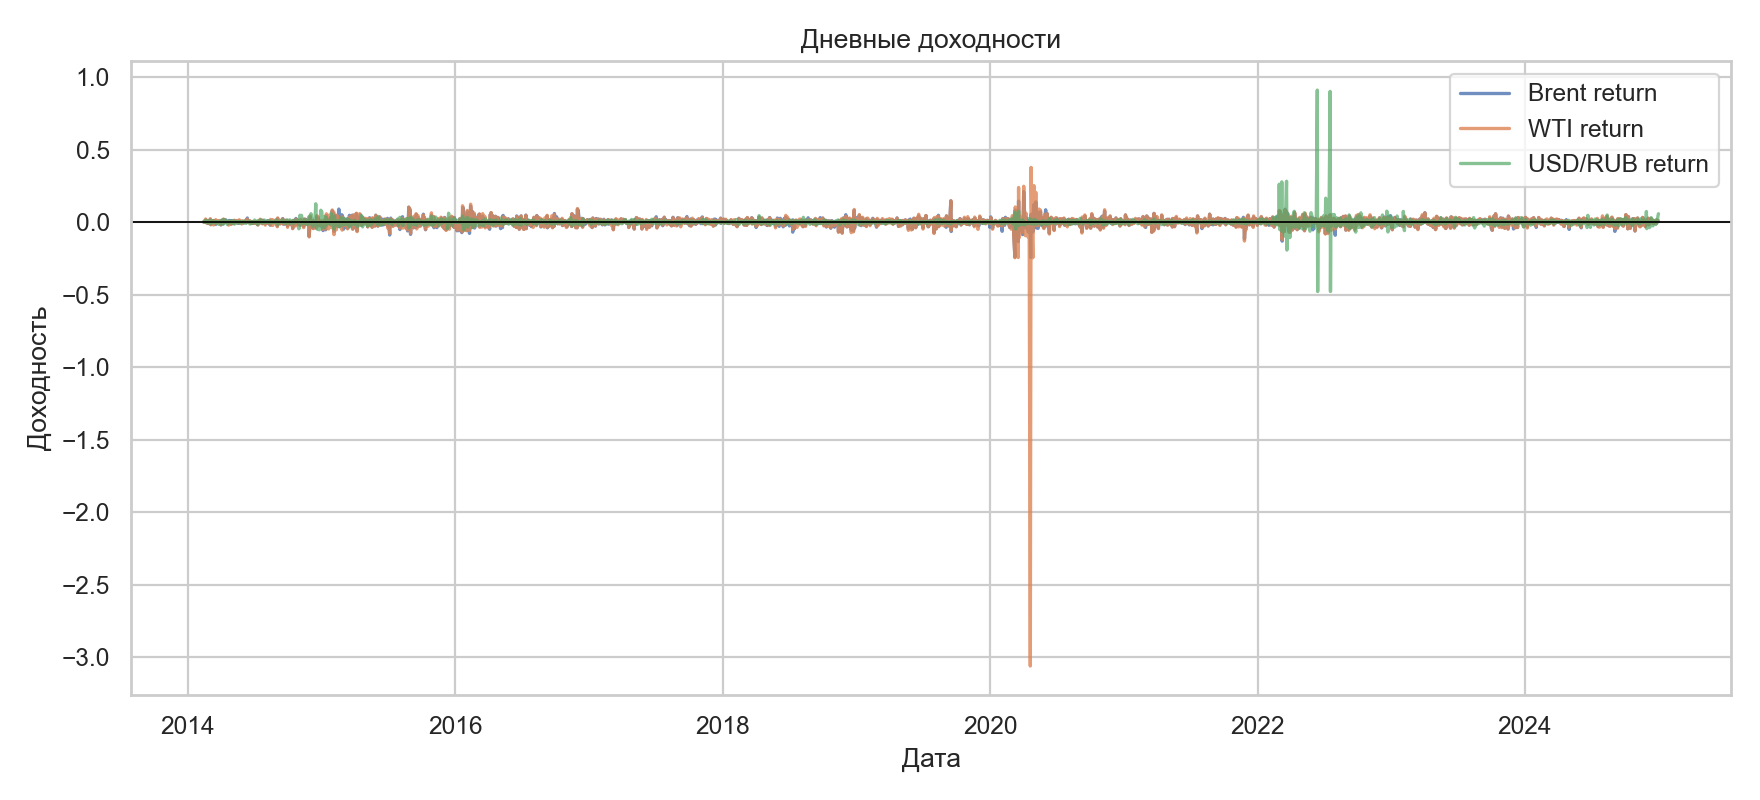

In [3]:
for name in ['oil_prices_daily.png', 'usdrub_daily.png', 'returns_daily.png']:
    display(Image(filename=str(Path('figures') / name)))

## 4. Корреляции

Корреляционная матрица показывает общую связь между уровнями и доходностями. Важно помнить, что корреляция не доказывает причинность.

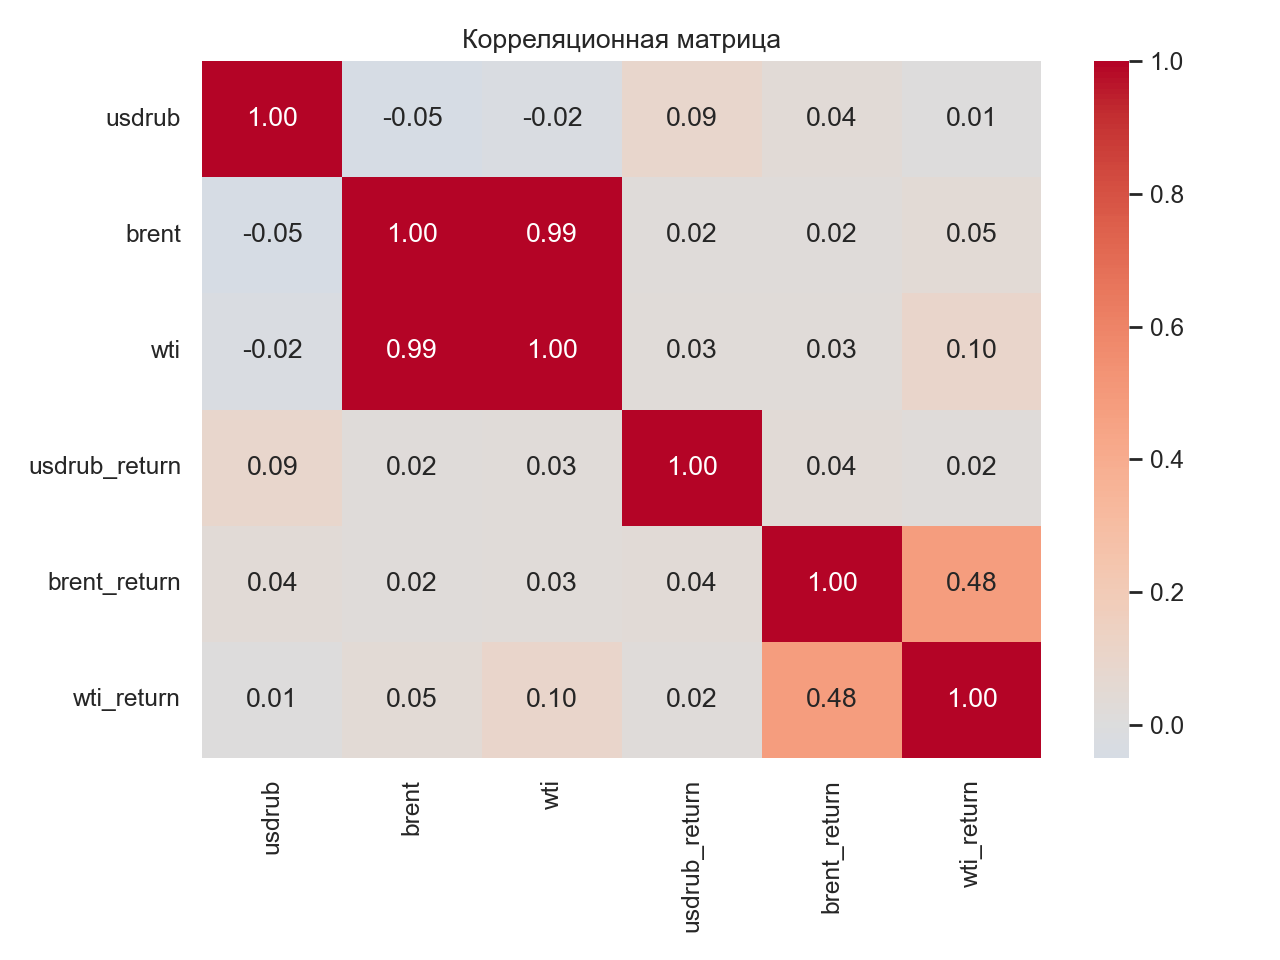

In [4]:
display(Image(filename='figures/correlation_heatmap_daily.png'))

## 5. Лаговый анализ

Лаги от -30 до +30 дней помогают посмотреть, есть ли задержанная реакция курса на изменение нефтяных цен.

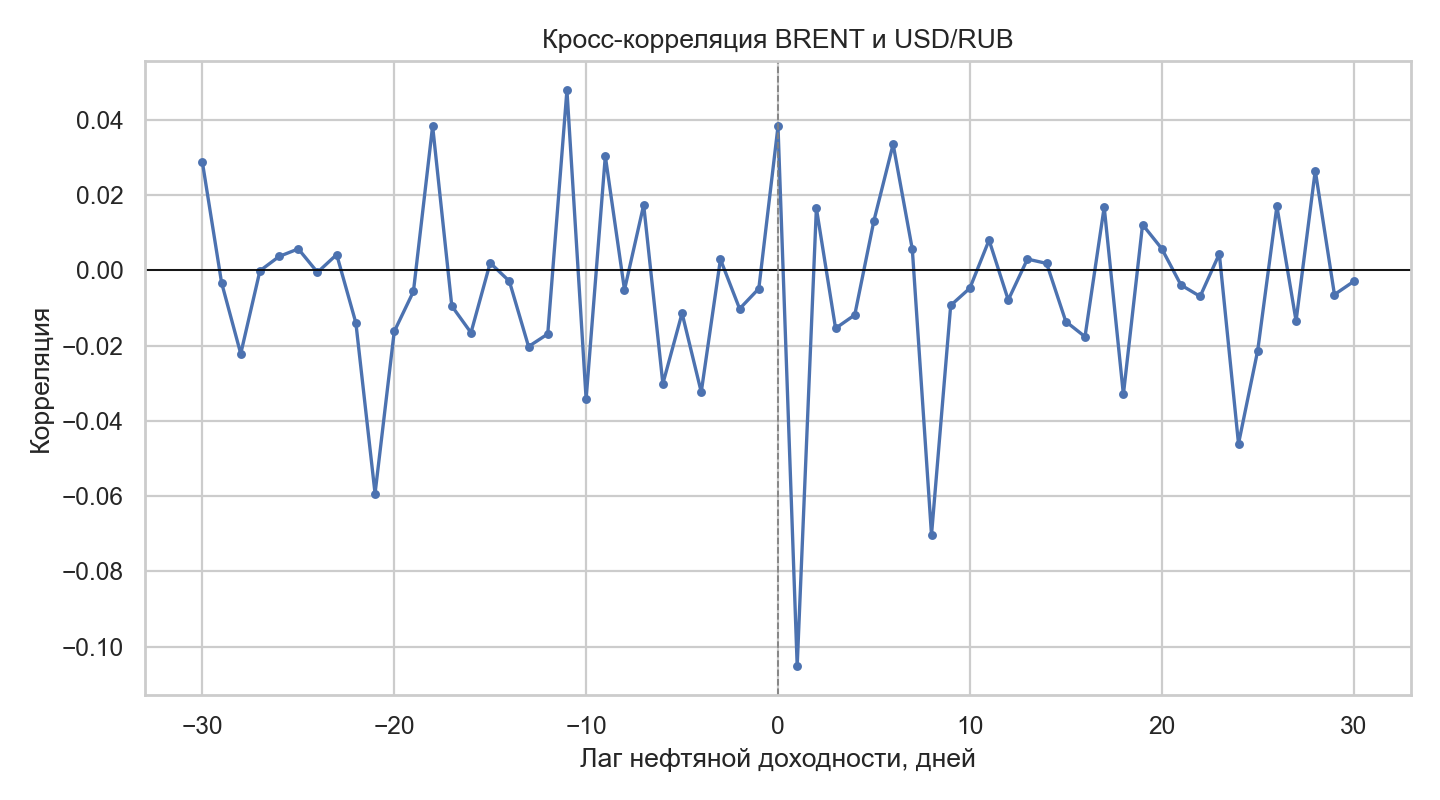

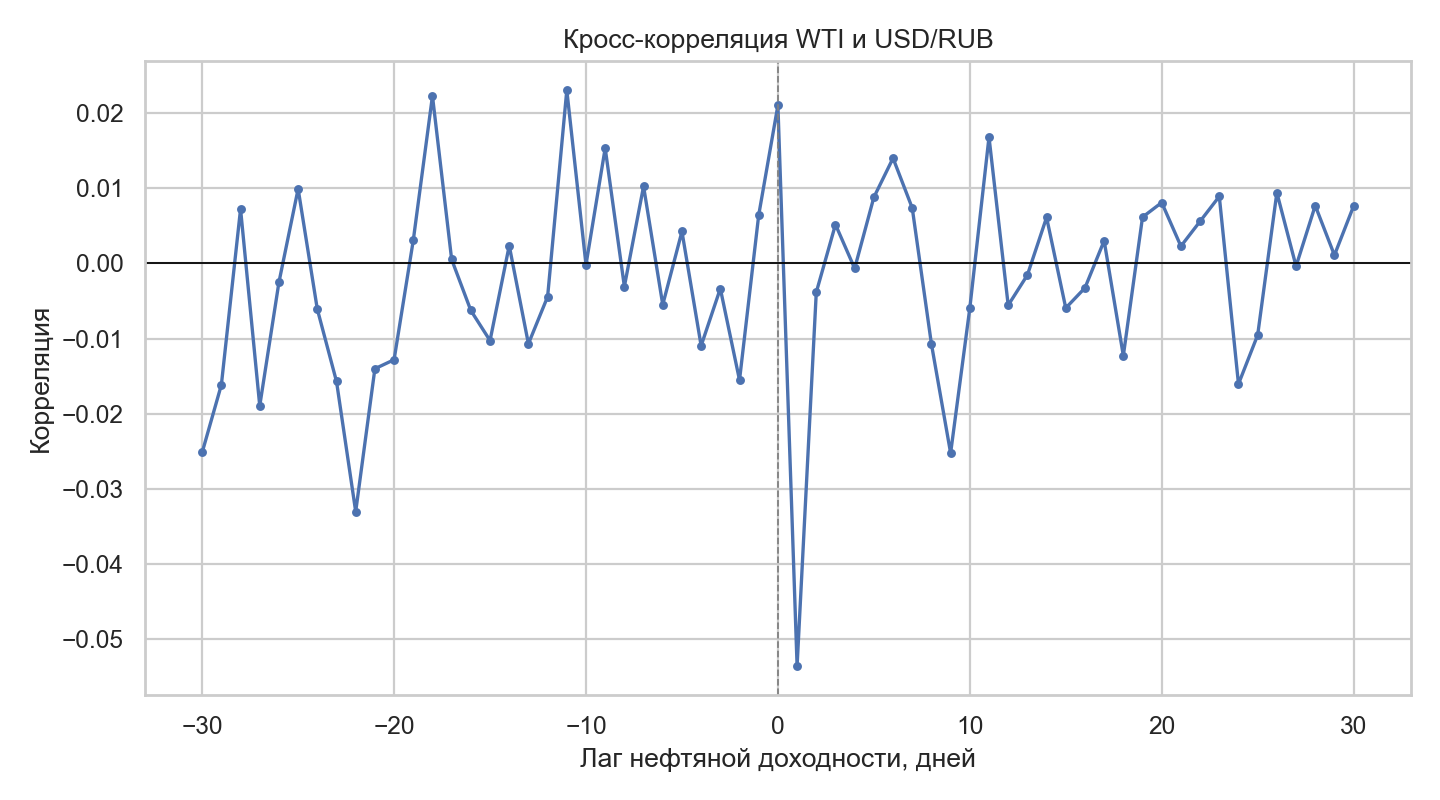

In [5]:
display(Image(filename='figures/cross_correlation_brent.png'))
display(Image(filename='figures/cross_correlation_wti.png'))

## 6. Месячные бенчмарки

Dubai доступен как месячная серия FRED/IMF, поэтому он рассматривается отдельно от дневных моделей.

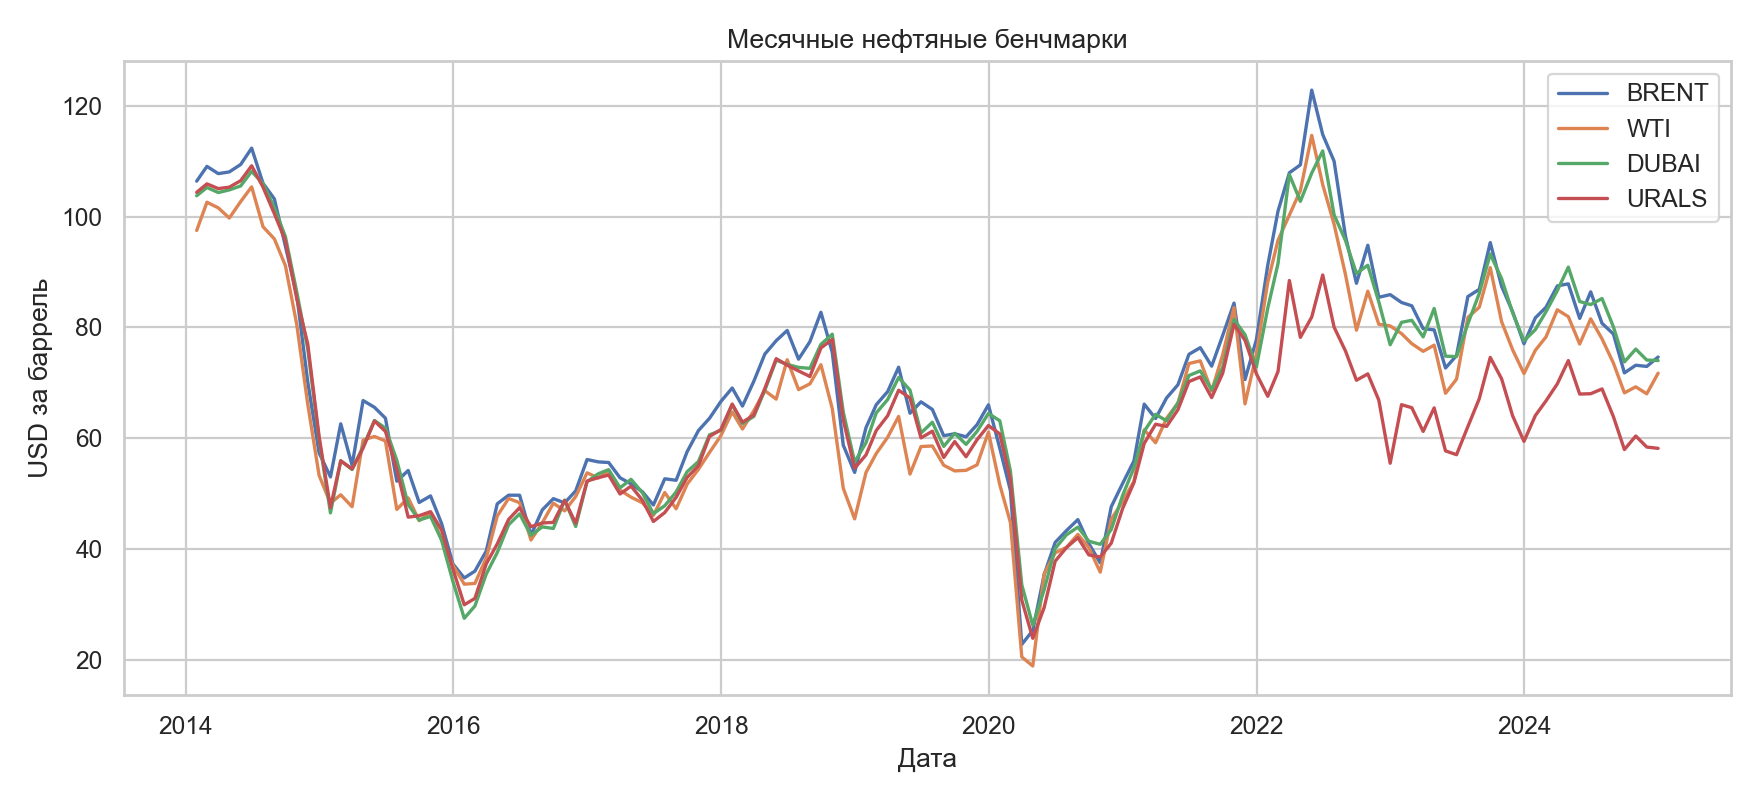

In [6]:
display(Image(filename='figures/monthly_benchmarks.png'))

## 7. Сравнение моделей

Для всех моделей считаются MAE, RMSE и R². Train/test делятся по времени, без перемешивания.

,model,MAE,RMSE,R2
0,Random Forest,19.016594,21.698552,-3.184202
1,Gradient Boosting,20.300580,22.665499,-3.565431
2,HistGradientBoosting,21.397756,23.640396,-3.966617
3,ARIMAX,24.305267,26.283033,-5.139063
4,OLS,26.854220,28.644385,-6.291723
5,Ridge,26.908814,28.734228,-6.337536
6,Lasso,27.013193,28.860470,-6.402151


,indicator,n_features,main_beta,main_p_value,MAE,RMSE,R2
0,wti,5,0.240689,9.927645e-05,26.839007,28.702250,-6.321213
1,brent,5,0.312850,5.505711e-08,27.307836,29.247458,-6.601992


,MAE,RMSE,R2
model,,,
Random Forest,12.950071,15.062856,-5.007343
Gradient Boosting,13.189027,15.109515,-5.561279
Lasso,14.864349,16.838903,-7.386522
Ridge,15.480771,17.852129,-8.339034


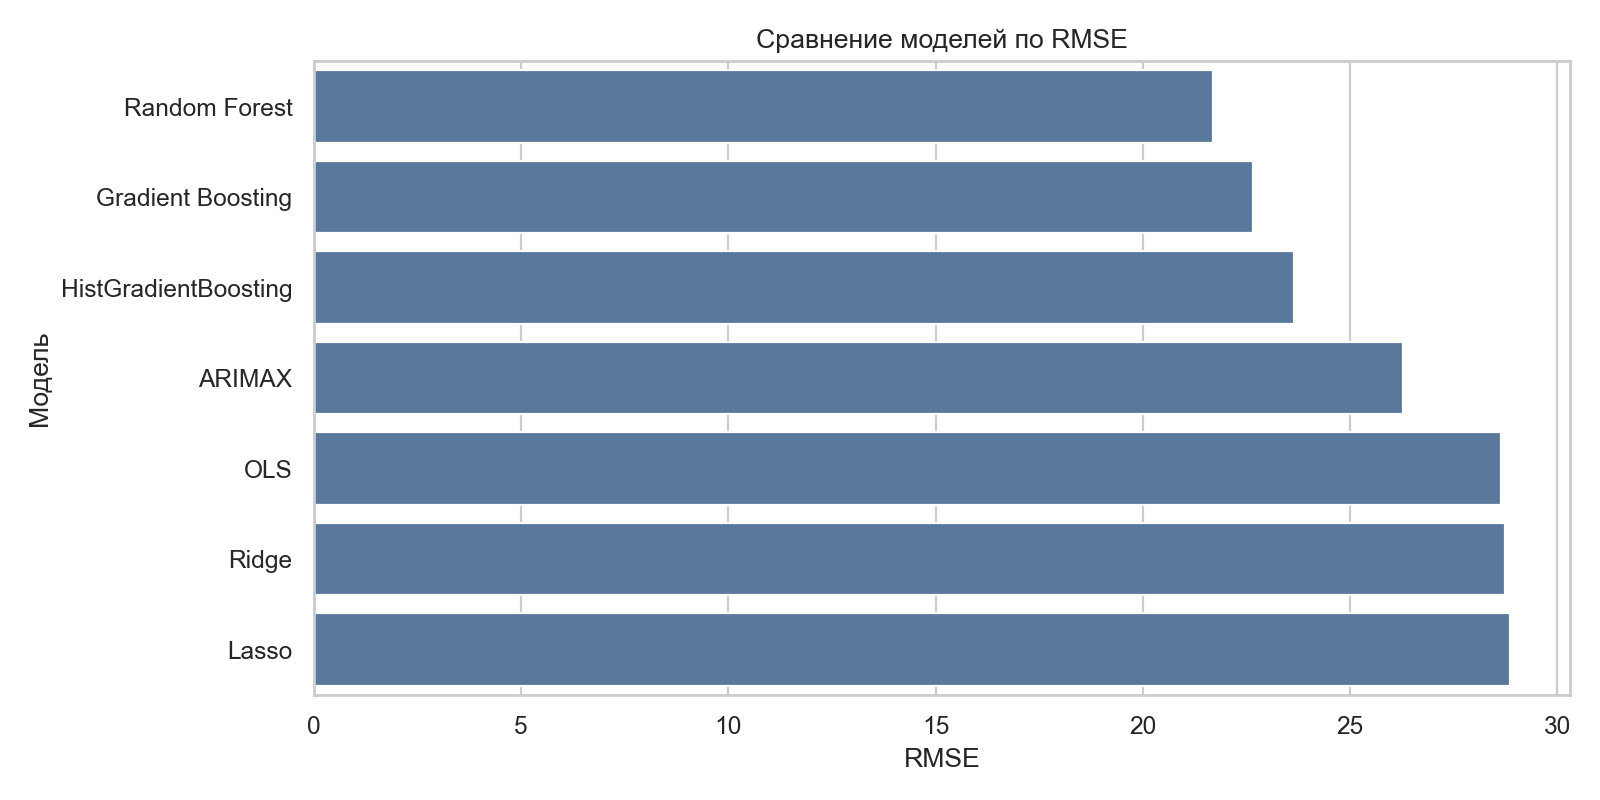

In [7]:
single = pd.read_csv('data/single_factor_results.csv')
cv = pd.read_csv('data/time_series_cv_results.csv')

display(results)
display(single)
display(cv.groupby('model')[['MAE', 'RMSE', 'R2']].mean().sort_values('RMSE'))
display(Image(filename='figures/model_comparison.png'))

## 8. Важность признаков

Random Forest показывает, какие нефтяные признаки чаще используются для объяснения курса.

,source,feature,importance
0,Ridge_coef,brent,1.545583
1,Ridge_coef,wti,4.037745
2,Ridge_coef,brent_return,0.134213
3,Ridge_coef,wti_return,-0.433130
4,Ridge_coef,brent_ma7,1.079971
5,Ridge_coef,brent_vol7,2.833584
6,Ridge_coef,brent_ma30,-5.647636
7,Ridge_coef,brent_vol30,4.168537
8,Ridge_coef,brent_lag1,-0.975792
9,Ridge_coef,brent_lag3,-0.093615


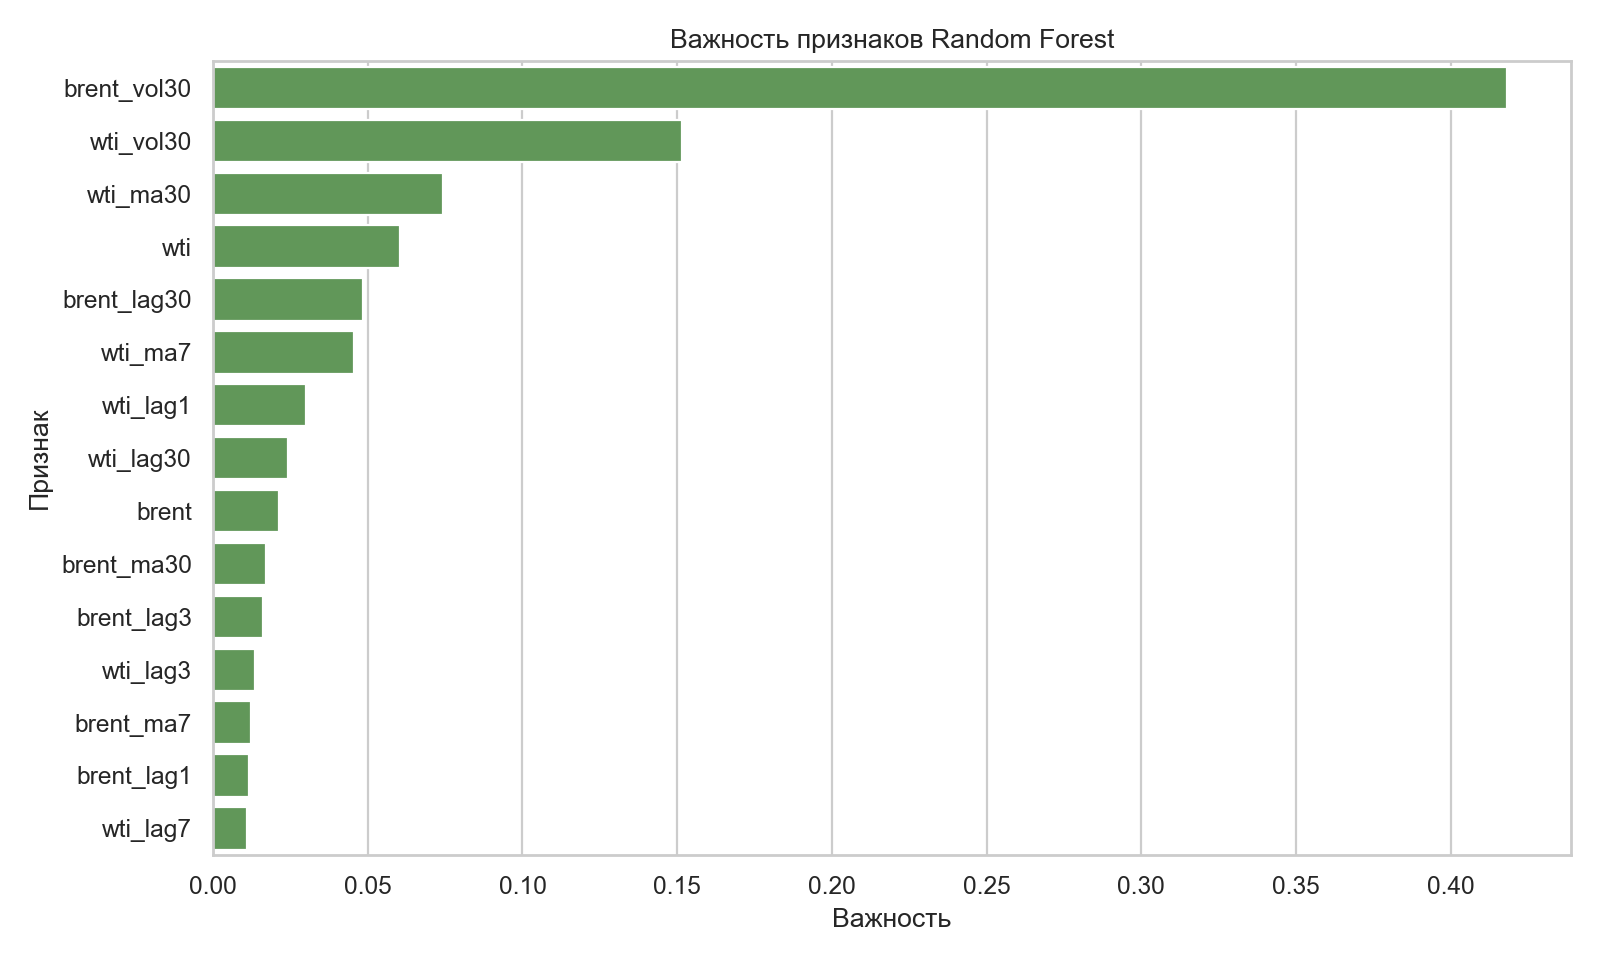

In [8]:
display(importance.head(20))
display(Image(filename='figures/feature_importance_rf.png'))

## 9. Прогноз на test-периоде

На графике сравнивается фактический USD/RUB и прогноз лучшей модели по RMSE.

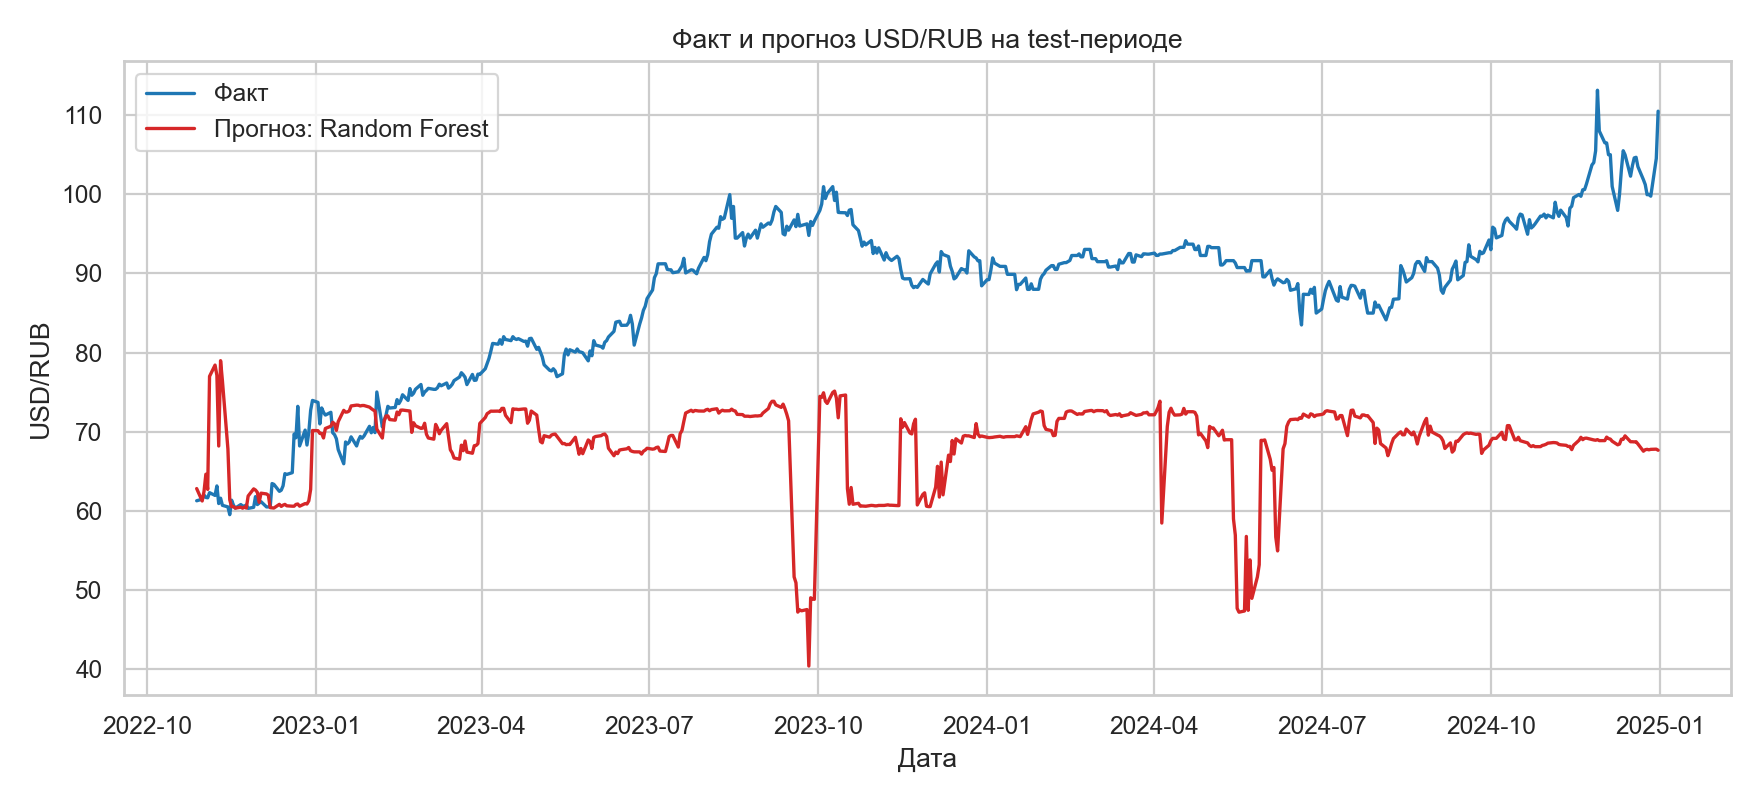

In [9]:
display(Image(filename='figures/forecast_actual_vs_predicted.png'))

## 10. Выводы

Нефть влияет на рубль, но не объясняет курс полностью. Brent и WTI близки между собой, поэтому возникает мультиколлинеарность. После 2014 и 2022 годов связь курса и нефти становится менее стабильной из-за санкций, ограничений и изменения структуры валютного рынка.